In [42]:
import pandas as pd
df=pd.read_csv('dataset_incendi_FIRMS.csv')

In [43]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 120

In [44]:
CSV_PATH = "dataset_incendi_FIRMS.csv"
CAMPIONE = 200_000

COL_LAT  = "latitude"
COL_LON  = "longitude"
COL_DATA = "acq_date"

FASCE = [
    ("2011–2015", 2011, 2015, "#4cc9f0", 0.25, 4),
    ("2016–2020", 2016, 2020, "#f9c74f", 0.30, 5),
    ("2021–2025", 2021, 2025, "#f3722c", 0.40, 7),
    ("2026",      2026, 2026, "#d00000", 0.60, 9),
]

BG_FIG  = "#0d1117"
BG_AX   = "#0d1b2a"
COL_BOR = "#3a5a7a"
COL_GRI = "#2a3a4a"

In [45]:
def carica_dati(path, campione=None):
    df = pd.read_csv(Path(path), low_memory=False)
    df[COL_LAT] = pd.to_numeric(df[COL_LAT], errors="coerce")
    df[COL_LON] = pd.to_numeric(df[COL_LON], errors="coerce")
    df["_anno"] = pd.to_datetime(df[COL_DATA], errors="coerce").dt.year
    df = df.dropna(subset=[COL_LAT, COL_LON, "_anno"])
    df["_anno"] = df["_anno"].astype(int)
    if campione and len(df) > campione:
        df = df.sample(campione, random_state=42)
    print(f"Caricati {len(df):,} punti | anni: {df['_anno'].min()}–{df['_anno'].max()}")
    return df

df = carica_dati(CSV_PATH, CAMPIONE)

Caricati 200,000 punti | anni: 2025–2026


  2011–2015: nessun dato
  2016–2020: nessun dato
  2021–2025: 148,677 punti
  2026: 51,323 punti


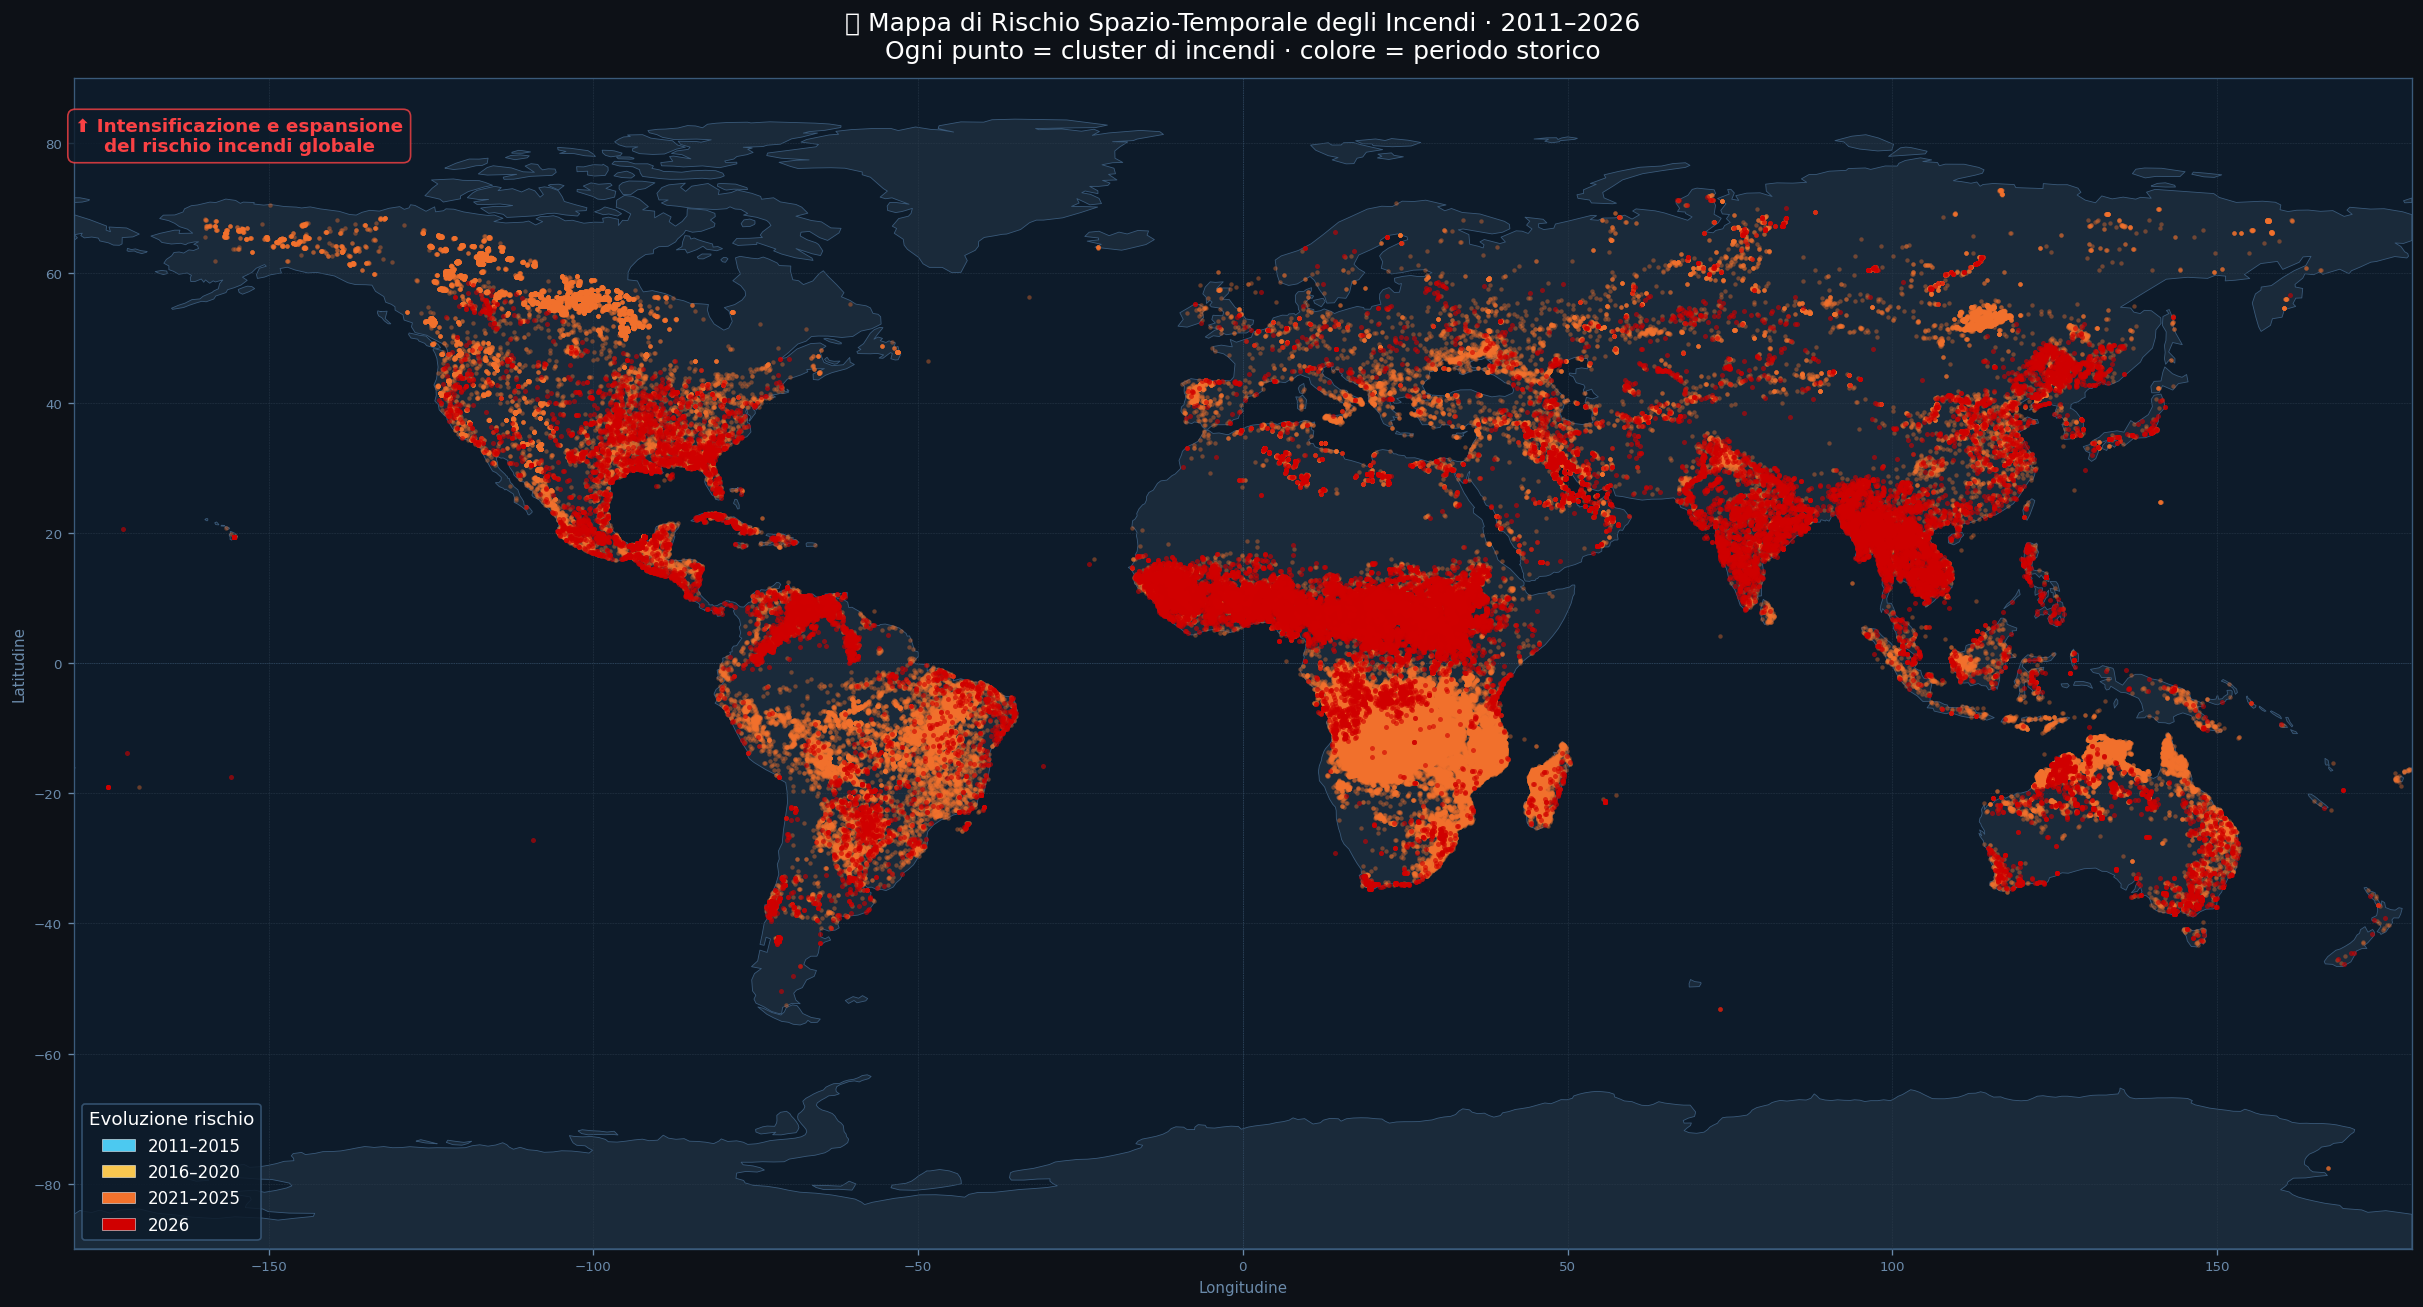

Salvato: mappa_rischio_scatter.png


In [ ]:
# ─── MAPPA SCATTER ────────────────────────────────────────
try:
    import geopandas as gpd, geodatasets
    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
except:
    world = None

fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor(BG_FIG)
ax.set_facecolor(BG_AX)

# sfondo paesi
if world is not None:
    world.plot(ax=ax, color="#1a2a3a", edgecolor=COL_BOR, linewidth=0.5, zorder=1)

# griglia
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(color=COL_GRI, linestyle="--", linewidth=0.3, zorder=0)
ax.axhline(0, color=COL_BOR, linewidth=0.4, linestyle=":")
ax.axvline(0, color=COL_BOR, linewidth=0.4, linestyle=":")

# scatter per fascia — le più recenti sopra
for label, anno_min, anno_max, colore, alpha, size in FASCE:
    sub = df[(df["_anno"] >= anno_min) & (df["_anno"] <= anno_max)]
    if sub.empty:
        print(f"  {label}: nessun dato")
        continue
    ax.scatter(
        sub[COL_LON], sub[COL_LAT],
        c=colore,
        s=size,
        alpha=alpha,
        linewidths=0,
        zorder=2,
        rasterized=True
    )
    print(f"  {label}: {len(sub):,} punti")

# assi
ax.set_xlabel("Longitudine", color="#6a8aaa", fontsize=9)
ax.set_ylabel("Latitudine",  color="#6a8aaa", fontsize=9)
ax.tick_params(colors="#6a8aaa", labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor(COL_BOR)

# titolo
ax.set_title(
    "🔥 Mappa di Rischio Spazio-Temporale degli Incendi · 2011–2026\n"
    "Ogni punto = cluster di incendi · colore = periodo storico",
    color="white", fontsize=15, pad=12
)

# legenda
handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=0.3, label=lbl)
    for lbl, *_, c, _, _ in FASCE
]
leg = ax.legend(
    handles=handles,
    loc="lower left",
    facecolor=BG_AX, edgecolor=COL_BOR,
    labelcolor="white", fontsize=10,
    title="Evoluzione rischio", title_fontsize=11,
    framealpha=0.85,
)
leg.get_title().set_color("white")

fig.text(
    0.13, 0.88,
    "⬆ Intensificazione e espansione\ndel rischio incendi globale",
    color="#f94144", fontsize=11, fontweight="bold", ha="center",
    bbox=dict(boxstyle="round,pad=0.4", facecolor=BG_AX,
              edgecolor="#f94144", alpha=0.8)
)

plt.tight_layout()

plt.show()